Starting Variational EM optimization...
EM Iteration 50/100, ELBO: -62.3000


/home/onoue/ws/tprt/src/tprt/tprt_cavi.py:77: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2255.)
  self.L_f = torch.triangular_solve(torch.eye(self.N, device=self.X.device), L_f_inv, upper=False)[0]


EM Iteration 100/100, ELBO: 133.2853

Optimization finished.


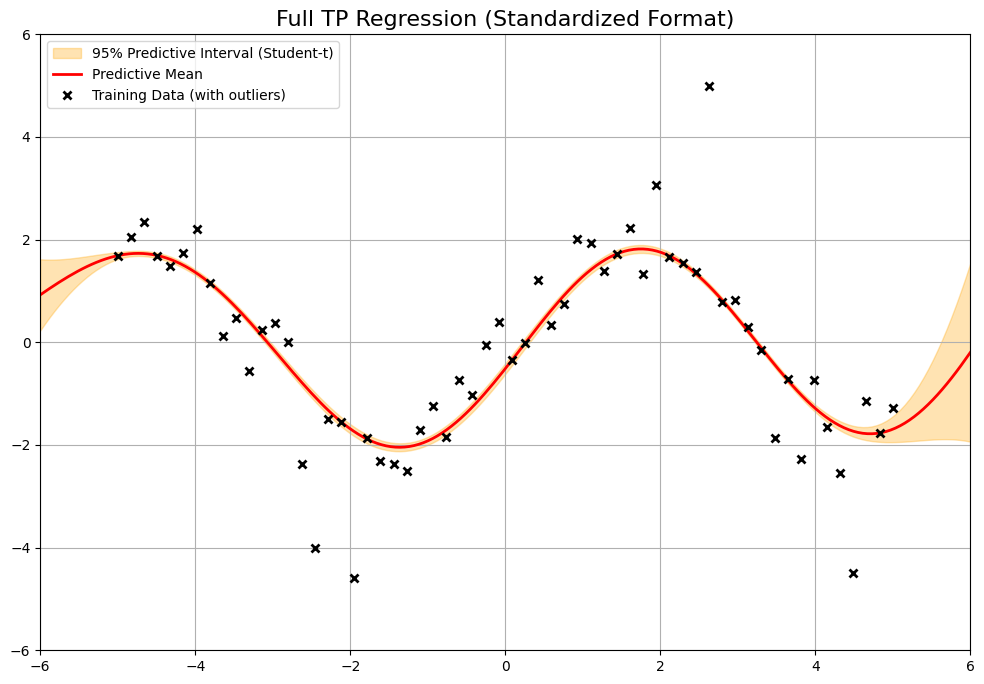

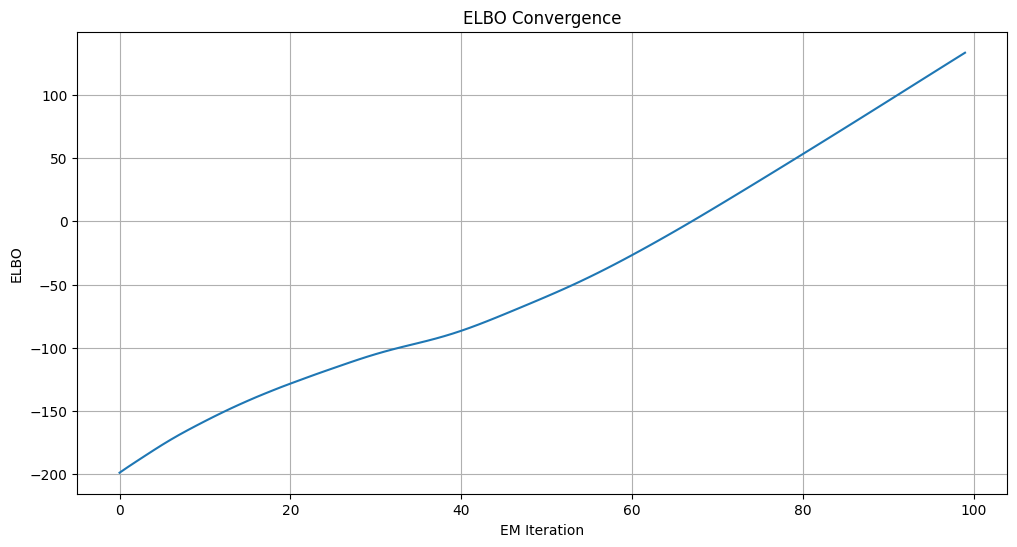

In [2]:
from tprt import TPRTFullBatch
import torch


if __name__ == '__main__':

    import matplotlib.pyplot as plt
    from scipy.stats import t
    torch.set_default_dtype(torch.float64)

    # 1. Generate data
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.5
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.3
    y_train = y_true + noise
    
    # Add some significant outliers
    outlier_indices = torch.randperm(N)[:8]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[15] = -4.0
    y_train[45] = 5.0

    # 2. Setup the non-sparse model
    model = TPRTFullBatch(
        X=X_train,
        y=y_train,
        nu_f=3.0,
        nu_e=3.0,
        kernel_lengthscale=1.0,
        kernel_variance=1.0,
        likelihood_sigma=1.0
    )

    # 3. Fit the model
    elbo_history = model.fit(max_iter_global=100, cavi_max_iter=15, lr=0.05)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    plt.title('Full TP Regression (Standardized Format)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    plt.figure(figsize=(12, 6))
    plt.plot(elbo_history)
    plt.title("ELBO Convergence")
    plt.xlabel("EM Iteration")
    plt.ylabel("ELBO")
    plt.grid(True)
    
    plt.show()

In [1]:
# evaluation.py
# 上記の `tprt.py` と同じディレクトリに配置して実行してください。

import os
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import mean_squared_error
from collections import defaultdict
import warnings
import time

# 作成した tprt.py からモデルをインポート
from tprt import TPRTFullBatch, TPRTFullBatch_Tang

# パフォーマンス向上のため、デフォルトのデータ型を設定
torch.set_default_dtype(torch.float64)
warnings.filterwarnings('ignore')

def load_data(dataset_path, dtype=torch.float64):
    """指定されたパスから学習データとテストデータを読み込む"""
    train_features_path = os.path.join(dataset_path, 'train_features.csv')
    train_target_path = os.path.join(dataset_path, 'train_target.csv')
    test_features_path = os.path.join(dataset_path, 'test_features.csv')
    test_target_path = os.path.join(dataset_path, 'test_target.csv')

    train_features = pd.read_csv(train_features_path, header=None).values
    train_target = pd.read_csv(train_target_path, header=None).values
    test_features = pd.read_csv(test_features_path, header=None).values
    test_target = pd.read_csv(test_target_path, header=None).values

    # Torchテンソルに変換
    X_train = torch.tensor(train_features, dtype=dtype)
    y_train = torch.tensor(train_target, dtype=dtype)
    X_test = torch.tensor(test_features, dtype=dtype)
    y_test = torch.tensor(test_target, dtype=dtype)
    
    return X_train, y_train, X_test, y_test

def evaluate_model(model_class, model_name, datasets_base_path):
    """指定されたモデルを全てのデータセットで評価する"""
    print(f"\n===== Evaluating Model: {model_name} =====")
    
    datasets = sorted([d for d in os.listdir(datasets_base_path) if os.path.isdir(os.path.join(datasets_base_path, d))])
    results = defaultdict(list)
    
    for dataset in datasets:
        print(f"--- Dataset: {dataset} ---")
        dataset_rmses = []
        dataset_times = []
        
        for i in range(10): # 10スプリットで評価
            split_path = os.path.join(datasets_base_path, dataset, f'split_{i}')
            
            try:
                X_train, y_train, X_test, y_test = load_data(split_path)
            except FileNotFoundError:
                print(f"  Split {i} not found. Skipping.")
                continue

            # モデルの初期化
            model = model_class(X_train, y_train)
            
            start_time = time.time()
            
            # モデルの学習 (fitメソッドを使用)
            # モデル内部のprint文はコメントアウト推奨
            if model_name == 'TPRT-VEM':
                model.fit(max_iter_global=100, cavi_max_iter=15, lr=0.05)
            elif model_name == 'TPRT-LA':
                model.fit(max_iter_global=100, mode_finding_iter=10, lr=0.01)

            # 予測
            with torch.no_grad():
                pred_mean, _, _ = model.predict(X_test)

            end_time = time.time()
            
            # 評価
            rmse = np.sqrt(mean_squared_error(y_test.numpy(), pred_mean.numpy()))
            dataset_rmses.append(rmse)
            dataset_times.append(end_time - start_time)
            
        if dataset_rmses:
            avg_rmse = np.mean(dataset_rmses)
            std_rmse = np.std(dataset_rmses)
            avg_time = np.mean(dataset_times)
            results[dataset] = {'avg_rmse': avg_rmse, 'std_rmse': std_rmse, 'avg_time_s': avg_time}
            print(f"  => Avg RMSE: {avg_rmse:.4f} ± {std_rmse:.4f} | Avg Time: {avg_time:.2f}s")
            
    return results

def main():
    """メインの実行関数"""
    base_path = 'datasets/dataset_tang_2017/'
    if not os.path.exists(base_path):
        print(f"Dataset directory not found at {base_path}")
        # Colabや他の環境用の代替パス
        base_path = '../datasets/dataset_tang_2017/'
        if not os.path.exists(base_path):
            print("Dataset directory not found. Please check the path.")
            return

    models_to_evaluate = {
        'TPRT-VEM': TPRTFullBatch,
        'TPRT-LA': TPRTFullBatch_Tang,
    }

    all_results = {}
    for name, model_cls in models_to_evaluate.items():
        all_results[name] = evaluate_model(model_cls, name, base_path)

    # 結果を整形してDataFrameで表示
    summary_data = []
    datasets = sorted(all_results['TPRT-VEM'].keys())

    for dataset in datasets:
        row = {'Dataset': dataset}
        for model_name in models_to_evaluate.keys():
            res = all_results[model_name].get(dataset)
            if res:
                row[f'{model_name}_RMSE'] = f"{res['avg_rmse']:.4f} ± {res['std_rmse']:.4f}"
                row[f'{model_name}_Time(s)'] = f"{res['avg_time_s']:.2f}"
        summary_data.append(row)

    results_df = pd.DataFrame(summary_data)
    print("\n\n--- 📊 Final Performance Summary 📊 ---")
    print(results_df.to_string(index=False))

    return results_df


results_df = main()
results_df

Dataset directory not found at datasets/dataset_tang_2017/

===== Evaluating Model: TPRT-VEM =====
--- Dataset: Bike ---
Starting Variational EM optimization...
EM Iteration 50/100, ELBO: -499.1079
EM Iteration 100/100, ELBO: 101.1022

Optimization finished.
Starting Variational EM optimization...
EM Iteration 50/100, ELBO: -527.4438
EM Iteration 100/100, ELBO: -221.8402

Optimization finished.
Starting Variational EM optimization...
EM Iteration 50/100, ELBO: -506.6088
EM Iteration 100/100, ELBO: 6.6289

Optimization finished.
Starting Variational EM optimization...
EM Iteration 50/100, ELBO: -539.0315
EM Iteration 100/100, ELBO: -187.3405

Optimization finished.
Starting Variational EM optimization...
EM Iteration 50/100, ELBO: -505.3898
EM Iteration 100/100, ELBO: -217.0231

Optimization finished.
Starting Variational EM optimization...
EM Iteration 50/100, ELBO: -533.1937
EM Iteration 100/100, ELBO: -275.1196

Optimization finished.
Starting Variational EM optimization...
EM Iterat

,Dataset,TPRT-VEM_RMSE,TPRT-VEM_Time(s),TPRT-LA_RMSE,TPRT-LA_Time(s)
0,Bike,0.9149 ± 0.1405,4.08,0.9601 ± 0.1402,58.42
1,Concrete,0.8238 ± 0.1854,5.22,1.0434 ± 0.0961,69.74
2,Diabetes,0.8918 ± 0.3241,0.75,1.0036 ± 0.4324,15.44
3,ELE,0.5870 ± 0.1570,10.54,0.8799 ± 0.1589,72.49
4,MPG,0.4645 ± 0.1100,7.23,0.4178 ± 0.0784,69.56
5,Machine_CPU,0.4802 ± 0.2831,2.83,0.7605 ± 0.6633,57.82
6,Neal,0.5899 ± 0.2323,0.56,0.5425 ± 0.1949,5.60
7,Neal_XOutlier,0.5470 ± 0.1885,0.38,1.0450 ± 0.0740,6.34


In [ ]:
# evaluation.py
# tprt パッケージと同じディレクトリに配置して実行してください。

import os
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import mean_squared_error
from collections import defaultdict
import warnings
import time
import logging
from pathlib import Path

# --- 作成した tprt パッケージからモデルをインポート ---
from tprt import TPRTFullBatch, TPRTFullBatch_Tang

# --- グローバル設定 ---
torch.set_default_dtype(torch.float64)
warnings.filterwarnings('ignore')

# === 1. ロギング設定の追加 ===
def setup_logging(log_file='evaluation_results.log'):
    """コンソールとファイルへのロギングを設定する"""
    # 古いログファイルを削除
    if os.path.exists(log_file):
        os.remove(log_file)
        
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(message)s',
        handlers=[
            logging.FileHandler(log_file),
            logging.StreamHandler() # コンソールにも出力
        ]
    )

# === 2. 実験パラメータの一元管理 ===
EVALUATION_CONFIG = {
    'TPRT-VEM': {
        'model_class': TPRTFullBatch,
        'init_params': {}, # デフォルトの初期化パラメータを使用
        'fit_params': {
            'max_iter_global': 100,
            'cavi_max_iter':20,
            'lr': 0.01
        }
    },
    'TPRT-LA': {
        'model_class': TPRTFullBatch_Tang,
        'init_params': { # 論文設定に合わせて初期値を指定
            'nu_f': 2.1,
            'nu_e': 2.1,
            'kernel_lengthscale': 1.0,
            'kernel_variance': 1.0,
            'likelihood_sigma': 1.0 # 論文設定 (σ^2=1.0) に合わせる
        },
        'fit_params': {
            'max_iter_global': 100,
            'mode_finding_iter': 20,
            'lr': 0.01
        }
    }
}

def load_data(dataset_path: Path, dtype=torch.float64):
    """指定されたパスから学習データとテストデータを読み込む"""
    train_features_path = dataset_path / 'train_features.csv'
    train_target_path = dataset_path / 'train_target.csv'
    test_features_path = dataset_path / 'test_features.csv'
    test_target_path = dataset_path / 'test_target.csv'

    train_features = pd.read_csv(train_features_path, header=None).values
    train_target = pd.read_csv(train_target_path, header=None).values
    test_features = pd.read_csv(test_features_path, header=None).values
    test_target = pd.read_csv(test_target_path, header=None).values

    # Torchテンソルに変換
    X_train = torch.tensor(train_features, dtype=dtype)
    y_train = torch.tensor(train_target, dtype=dtype)
    X_test = torch.tensor(test_features, dtype=dtype)
    y_test = torch.tensor(test_target, dtype=dtype)
    
    return X_train, y_train, X_test, y_test

def evaluate_model(model_name, config, datasets_base_path: Path):
    """指定されたモデルを全てのデータセットで評価する"""
    logging.info(f"\n===== Evaluating Model: {model_name} =====")
    
    datasets = sorted([d.name for d in datasets_base_path.iterdir() if d.is_dir()])
    results = defaultdict(list)
    
    model_class = config['model_class']
    init_params = config['init_params']
    fit_params = config['fit_params']
    
    for dataset in datasets:
        logging.info(f"--- Dataset: {dataset} ---")
        dataset_rmses = []
        dataset_times = []
        
        for i in range(10): # 10スプリットで評価
            split_path = datasets_base_path / dataset / f'split_{i}'
            
            try:
                X_train, y_train, X_test, y_test = load_data(split_path)
            except FileNotFoundError:
                logging.warning(f"  Split {i} for dataset {dataset} not found. Skipping.")
                continue

            # モデルの初期化 (設定ファイルからパラメータを渡す)
            model = model_class(X_train, y_train, **init_params)
            
            start_time = time.time()
            
            # モデルの学習 (設定ファイルからパラメータを渡す)
            # モデル内部のprint文はパフォーマンスのためコメントアウト推奨
            logging.info(f"  Training on split {i}...")
            model.fit(**fit_params)
            logging.info(f"  Training finished for split {i}.")

            # 予測
            with torch.no_grad():
                pred_mean, _, _ = model.predict(X_test)

            end_time = time.time()
            
            # 評価
            rmse = np.sqrt(mean_squared_error(y_test.numpy(), pred_mean.numpy()))
            dataset_rmses.append(rmse)
            dataset_times.append(end_time - start_time)
            
        if dataset_rmses:
            avg_rmse = np.mean(dataset_rmses)
            std_rmse = np.std(dataset_rmses)
            avg_time = np.mean(dataset_times)
            results[dataset] = {'avg_rmse': avg_rmse, 'std_rmse': std_rmse, 'avg_time_s': avg_time}
            logging.info(f"  => Avg RMSE: {avg_rmse:.4f} ± {std_rmse:.4f} | Avg Time: {avg_time:.2f}s")
            
    return results

def main():
    """メインの実行関数"""
    setup_logging() # ロギングを開始

    base_path_str = 'datasets/dataset_tang_2017/'
    base_path = Path(base_path_str)
    
    if not base_path.exists():
        logging.warning(f"Dataset directory not found at {base_path_str}")
        # Colabや他の環境用の代替パス
        base_path_str_alt = '../datasets/dataset_tang_2017/'
        base_path = Path(base_path_str_alt)
        if not base_path.exists():
            logging.error("Dataset directory not found. Please check the path.")
            return

    all_results = {}
    for name, config in EVALUATION_CONFIG.items():
        all_results[name] = evaluate_model(name, config, base_path)

    # 結果を整形してDataFrameで表示
    summary_data = []
    # 最初のモデルの結果からデータセット一覧を取得
    datasets = sorted(all_results[list(EVALUATION_CONFIG.keys())[0]].keys())

    for dataset in datasets:
        row = {'Dataset': dataset}
        for model_name in EVALUATION_CONFIG.keys():
            res = all_results[model_name].get(dataset)
            if res:
                row[f'{model_name}_RMSE'] = f"{res['avg_rmse']:.4f} ± {res['std_rmse']:.4f}"
                row[f'{model_name}_Time(s)'] = f"{res['avg_time_s']:.2f}"
        summary_data.append(row)

    results_df = pd.DataFrame(summary_data)
    logging.info("\n\n--- 📊 Final Performance Summary 📊 ---")
    
    # DataFrameをログに出力
    summary_string = results_df.to_string(index=False)
    logging.info(f"\n{summary_string}")

    return results_df


if __name__ == "__main__":
    results_df = main()

2025-07-11 15:15:07,043 - WARNING - Dataset directory not found at datasets/dataset_tang_2017/
2025-07-11 15:15:07,043 - INFO - 
===== Evaluating Model: TPRT-VEM =====
2025-07-11 15:15:07,044 - INFO - --- Dataset: Bike ---
2025-07-11 15:15:07,049 - INFO -   Training on split 0...


Starting Variational EM optimization...
EM Iteration 50/100, ELBO: -499.1079


2025-07-11 15:15:12,554 - INFO -   Training finished for split 0.
2025-07-11 15:15:12,564 - INFO -   Training on split 1...


EM Iteration 100/100, ELBO: 101.1022

Optimization finished.
Starting Variational EM optimization...
EM Iteration 50/100, ELBO: -527.4438


2025-07-11 15:15:16,879 - INFO -   Training finished for split 1.
2025-07-11 15:15:16,886 - INFO -   Training on split 2...


...

Iteration 100/100, Loss: -229.6601

Optimization finished.
Starting optimization...
Iteration 50/100, Loss: -208.0787


2025-07-11 16:27:24,521 - INFO -   Training finished for split 8.
2025-07-11 16:27:24,525 - INFO -   Training on split 9...


Iteration 100/100, Loss: -229.5329

Optimization finished.
Starting optimization...
Iteration 50/100, Loss: -209.7278


2025-07-11 16:27:27,737 - INFO -   Training finished for split 9.
2025-07-11 16:27:27,739 - INFO -   => Avg RMSE: 0.9662 ± 0.0668 | Avg Time: 3.39s
2025-07-11 16:27:27,740 - INFO - 

--- 📊 Final Performance Summary 📊 ---
2025-07-11 16:27:27,742 - INFO - 
      Dataset   TPRT-VEM_RMSE TPRT-VEM_Time(s)    TPRT-LA_RMSE TPRT-LA_Time(s)
         Bike 0.9149 ± 0.1405             4.61 1.0090 ± 0.1354           70.31
     Concrete 0.8238 ± 0.1854             5.18 1.0540 ± 0.0964           74.31
     Diabetes 0.8918 ± 0.3241             0.75 0.9599 ± 0.4505           15.48
          ELE 0.5870 ± 0.1570             9.92 0.9547 ± 0.1467          123.17
          MPG 0.4645 ± 0.1100             6.85 0.8723 ± 0.0894           52.28
  Machine_CPU 0.4802 ± 0.2831             2.61 0.8750 ± 0.6191           58.97
         Neal 0.5899 ± 0.2323             0.58 0.9657 ± 0.0679            5.02
Neal_XOutlier 0.5470 ± 0.1885             0.56 0.9662 ± 0.0668            3.39


Iteration 100/100, Loss: -230.4845

Optimization finished.


In [2]:
results_df

,Dataset,TPRT-VEM_RMSE,TPRT-VEM_Time(s),TPRT-LA_RMSE,TPRT-LA_Time(s)
0,Bike,0.9149 ± 0.1405,4.61,1.0090 ± 0.1354,70.31
1,Concrete,0.8238 ± 0.1854,5.18,1.0540 ± 0.0964,74.31
2,Diabetes,0.8918 ± 0.3241,0.75,0.9599 ± 0.4505,15.48
3,ELE,0.5870 ± 0.1570,9.92,0.9547 ± 0.1467,123.17
4,MPG,0.4645 ± 0.1100,6.85,0.8723 ± 0.0894,52.28
5,Machine_CPU,0.4802 ± 0.2831,2.61,0.8750 ± 0.6191,58.97
6,Neal,0.5899 ± 0.2323,0.58,0.9657 ± 0.0679,5.02
7,Neal_XOutlier,0.5470 ± 0.1885,0.56,0.9662 ± 0.0668,3.39


In [3]:
# evaluation.py
# tprt パッケージと同じディレクトリに配置して実行してください。

import os
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import mean_squared_error
from collections import defaultdict
import warnings
import time
import logging
from pathlib import Path

# --- 作成した tprt パッケージからモデルをインポート ---
from tprt import TPRTFullBatch, TPRTFullBatch_Tang

# --- グローバル設定 ---
torch.set_default_dtype(torch.float64)
warnings.filterwarnings('ignore')

# === 1. ロギング設定の追加 ===
def setup_logging(log_file='evaluation_results.log'):
    """コンソールとファイルへのロギングを設定する"""
    # 古いログファイルを削除
    if os.path.exists(log_file):
        os.remove(log_file)
        
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(message)s',
        handlers=[
            logging.FileHandler(log_file),
            logging.StreamHandler() # コンソールにも出力
        ]
    )

# === 2. 実験パラメータの一元管理 ===
EVALUATION_CONFIG = {
    'TPRT-VEM': {
        'model_class': TPRTFullBatch,
        'init_params': {
            'nu_f': 2+1e-6,
            'nu_e': 2+1e-6,
            'kernel_lengthscale': 1.0,
            'kernel_variance': 1.0,
            'likelihood_sigma': 1.0, 
        }, # デフォルトの初期化パラメータを使用
        'fit_params': {
            'max_iter_global': 100,
            'cavi_max_iter':20,
            'lr': 0.01
        }
    },
    'TPRT-LA': {
        'model_class': TPRTFullBatch_Tang,
        'init_params': { # 論文設定に合わせて初期値を指定
            'nu_f': 2+1e-6,
            'nu_e': 2+1e-6,
            'kernel_lengthscale': 1.0,
            'kernel_variance': 1.0,
            'likelihood_sigma': 1.0 # 論文設定 (σ^2=1.0) に合わせる
        },
        'fit_params': {
            'max_iter_global': 100,
            'mode_finding_iter': 20,
            'lr': 0.01
        }
    }
}

def load_data(dataset_path: Path, dtype=torch.float64):
    """指定されたパスから学習データとテストデータを読み込む"""
    train_features_path = dataset_path / 'train_features.csv'
    train_target_path = dataset_path / 'train_target.csv'
    test_features_path = dataset_path / 'test_features.csv'
    test_target_path = dataset_path / 'test_target.csv'

    train_features = pd.read_csv(train_features_path, header=None).values
    train_target = pd.read_csv(train_target_path, header=None).values
    test_features = pd.read_csv(test_features_path, header=None).values
    test_target = pd.read_csv(test_target_path, header=None).values

    # Torchテンソルに変換
    X_train = torch.tensor(train_features, dtype=dtype)
    y_train = torch.tensor(train_target, dtype=dtype)
    X_test = torch.tensor(test_features, dtype=dtype)
    y_test = torch.tensor(test_target, dtype=dtype)
    
    return X_train, y_train, X_test, y_test

def evaluate_model(model_name, config, datasets_base_path: Path):
    """指定されたモデルを全てのデータセットで評価する"""
    logging.info(f"\n===== Evaluating Model: {model_name} =====")
    
    datasets = sorted([d.name for d in datasets_base_path.iterdir() if d.is_dir()])
    results = defaultdict(list)
    
    model_class = config['model_class']
    init_params = config['init_params']
    fit_params = config['fit_params']
    
    for dataset in datasets:
        logging.info(f"--- Dataset: {dataset} ---")
        dataset_rmses = []
        dataset_times = []
        
        for i in range(10): # 10スプリットで評価
            split_path = datasets_base_path / dataset / f'split_{i}'
            
            try:
                X_train, y_train, X_test, y_test = load_data(split_path)
            except FileNotFoundError:
                logging.warning(f"  Split {i} for dataset {dataset} not found. Skipping.")
                continue

            # モデルの初期化 (設定ファイルからパラメータを渡す)
            model = model_class(X_train, y_train, **init_params)
            
            start_time = time.time()
            
            # モデルの学習 (設定ファイルからパラメータを渡す)
            # モデル内部のprint文はパフォーマンスのためコメントアウト推奨
            logging.info(f"  Training on split {i}...")
            model.fit(**fit_params)
            logging.info(f"  Training finished for split {i}.")

            # 予測
            with torch.no_grad():
                pred_mean, _, _ = model.predict(X_test)

            end_time = time.time()
            
            # 評価
            rmse = np.sqrt(mean_squared_error(y_test.numpy(), pred_mean.numpy()))
            dataset_rmses.append(rmse)
            dataset_times.append(end_time - start_time)
            
        if dataset_rmses:
            avg_rmse = np.mean(dataset_rmses)
            std_rmse = np.std(dataset_rmses)
            avg_time = np.mean(dataset_times)
            results[dataset] = {'avg_rmse': avg_rmse, 'std_rmse': std_rmse, 'avg_time_s': avg_time}
            logging.info(f"  => Avg RMSE: {avg_rmse:.4f} ± {std_rmse:.4f} | Avg Time: {avg_time:.2f}s")
            
    return results

def main():
    """メインの実行関数"""
    setup_logging() # ロギングを開始

    base_path_str = 'datasets/dataset_tang_2017/'
    base_path = Path(base_path_str)
    
    if not base_path.exists():
        logging.warning(f"Dataset directory not found at {base_path_str}")
        # Colabや他の環境用の代替パス
        base_path_str_alt = '../datasets/dataset_tang_2017/'
        base_path = Path(base_path_str_alt)
        if not base_path.exists():
            logging.error("Dataset directory not found. Please check the path.")
            return

    all_results = {}
    for name, config in EVALUATION_CONFIG.items():
        all_results[name] = evaluate_model(name, config, base_path)

    # 結果を整形してDataFrameで表示
    summary_data = []
    # 最初のモデルの結果からデータセット一覧を取得
    datasets = sorted(all_results[list(EVALUATION_CONFIG.keys())[0]].keys())

    for dataset in datasets:
        row = {'Dataset': dataset}
        for model_name in EVALUATION_CONFIG.keys():
            res = all_results[model_name].get(dataset)
            if res:
                row[f'{model_name}_RMSE'] = f"{res['avg_rmse']:.4f} ± {res['std_rmse']:.4f}"
                row[f'{model_name}_Time(s)'] = f"{res['avg_time_s']:.2f}"
        summary_data.append(row)

    results_df = pd.DataFrame(summary_data)
    logging.info("\n\n--- 📊 Final Performance Summary 📊 ---")
    
    # DataFrameをログに出力
    summary_string = results_df.to_string(index=False)
    logging.info(f"\n{summary_string}")

    return results_df


if __name__ == "__main__":
    results_df = main()

2025-07-11 17:14:41,157 - WARNING - Dataset directory not found at datasets/dataset_tang_2017/
2025-07-11 17:14:41,157 - INFO - 
===== Evaluating Model: TPRT-VEM =====
2025-07-11 17:14:41,158 - INFO - --- Dataset: Bike ---
2025-07-11 17:14:41,161 - INFO -   Training on split 0...


Starting Variational EM optimization...
EM Iteration 50/100, ELBO: -666.3214


2025-07-11 17:14:45,624 - INFO -   Training finished for split 0.
2025-07-11 17:14:45,630 - INFO -   Training on split 1...


EM Iteration 100/100, ELBO: -554.4822

Optimization finished.
Starting Variational EM optimization...
EM Iteration 50/100, ELBO: -677.7297


2025-07-11 17:14:49,972 - INFO -   Training finished for split 1.
2025-07-11 17:14:49,979 - INFO -   Training on split 2...


...

Iteration 100/100, Loss: -230.4326

Optimization finished.
Starting optimization...
Iteration 50/100, Loss: -208.8006


2025-07-11 19:20:16,170 - INFO -   Training finished for split 8.
2025-07-11 19:20:16,174 - INFO -   Training on split 9...


Iteration 100/100, Loss: -230.3119

Optimization finished.
Starting optimization...
Iteration 50/100, Loss: -210.4421


2025-07-11 19:20:19,414 - INFO -   Training finished for split 9.
2025-07-11 19:20:19,416 - INFO -   => Avg RMSE: 0.9662 ± 0.0668 | Avg Time: 3.40s
2025-07-11 19:20:19,417 - INFO - 

--- 📊 Final Performance Summary 📊 ---
2025-07-11 19:20:19,419 - INFO - 
      Dataset   TPRT-VEM_RMSE TPRT-VEM_Time(s)    TPRT-LA_RMSE TPRT-LA_Time(s)
         Bike 0.9213 ± 0.1418             4.53 1.0130 ± 0.1354          151.59
     Concrete 1.6911 ± 0.4336             2.62 1.0470 ± 0.0956          157.36
     Diabetes 1.4268 ± 0.8140             0.70 0.9615 ± 0.4506           29.15
          ELE 0.8386 ± 0.7292            10.25 0.9266 ± 0.1530          150.78
          MPG 0.5207 ± 0.1144             5.20 0.8815 ± 0.0898          108.90
  Machine_CPU 0.6063 ± 0.5057             1.20 0.8546 ± 0.6287          122.16
         Neal 1.6257 ± 0.7656             0.38 0.9658 ± 0.0678            4.99
Neal_XOutlier 4.3361 ± 1.1600             0.55 0.9662 ± 0.0668            3.40


Iteration 100/100, Loss: -231.2572

Optimization finished.
